# House Price Prediction with PySpark

This notebook builds and evaluates a regression model that predicts house sale prices from the attributes in the House Prices training dataset.

It was converted from the Apache Zeppelin notebook **`20 - House-Price-Prediction.zpln`** and modernized for a Python/Jupyter environment using current PySpark APIs.

## Learning objectives

- Load CSV data into a Spark DataFrame
- Inspect and prepare numeric and categorical features
- Build a reusable Spark ML pipeline
- Train a linear regression model
- Generate predictions
- Evaluate the model with RMSE, MAE, and $R^2$
- Visualize predicted versus actual sale prices

## 1. Import Spark SQL and Spark ML libraries

The notebook uses a Spark ML `Pipeline` so that missing-value handling, categorical encoding, feature assembly, model training, and test-time transformations follow the same sequence.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.feature import Imputer, OneHotEncoder, StringIndexer, VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

Matplotlib is building the font cache; this may take a moment.


In [2]:
spark = (
    SparkSession.builder
    .appName("House Price Prediction")
    .master("local[*]")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print(f"Spark version: {spark.version}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/27 18:27:00 WARN Utils: Your hostname, Roberts-MacBook-Air.local, resolves to a loopback address: 127.0.0.1; using 10.0.0.92 instead (on interface en0)
26/07/27 18:27:00 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/07/27 18:27:00 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.2.0


## 2. Load the source data

Set `DATA_PATH` to the location of the Kaggle House Prices `train.csv` file. The original Zeppelin notebook used an absolute path that was specific to one computer; this version uses a portable project-relative path by default.

Recommended location:

```text
data/raw/house-prices/train.csv
```

In [4]:
DATA_PATH = Path("../data/raw/house-prices/train.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH.resolve()}. "
        "Place the House Prices train.csv file there or update DATA_PATH."
    )

house_df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(str(DATA_PATH))
)

print(f"Rows: {house_df.count():,}")
print(f"Columns: {len(house_df.columns)}")
house_df.show(5, truncate=False)

Rows: 1,460
Columns: 81


26/07/27 18:30:04 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+---+----------+--------+-----------+-------+------+-----+--------+-----------+---------+---------+---------+------------+----------+----------+--------+----------+-----------+-----------+---------+------------+---------+--------+-----------+-----------+----------+----------+---------+---------+----------+--------+--------+------------+------------+----------+------------+----------+---------+-----------+-------+---------+----------+----------+--------+--------+------------+---------+------------+------------+--------+--------+------------+------------+-----------+------------+----------+----------+-----------+----------+-----------+------------+----------+----------+----------+----------+----------+----------+-----------+-------------+---------+-----------+--------+------+-----+-----------+-------+------+------+--------+-------------+---------+
|Id |MSSubClass|MSZoning|LotFrontage|LotArea|Street|Alley|LotShape|LandContour|Utilities|LotConfig|LandSlope|Neighborhood|Condition1|Condition

In [5]:
house_df.printSchema()

root
 |-- Id: integer (nullable = true)
 |-- MSSubClass: integer (nullable = true)
 |-- MSZoning: string (nullable = true)
 |-- LotFrontage: string (nullable = true)
 |-- LotArea: integer (nullable = true)
 |-- Street: string (nullable = true)
 |-- Alley: string (nullable = true)
 |-- LotShape: string (nullable = true)
 |-- LandContour: string (nullable = true)
 |-- Utilities: string (nullable = true)
 |-- LotConfig: string (nullable = true)
 |-- LandSlope: string (nullable = true)
 |-- Neighborhood: string (nullable = true)
 |-- Condition1: string (nullable = true)
 |-- Condition2: string (nullable = true)
 |-- BldgType: string (nullable = true)
 |-- HouseStyle: string (nullable = true)
 |-- OverallQual: integer (nullable = true)
 |-- OverallCond: integer (nullable = true)
 |-- YearBuilt: integer (nullable = true)
 |-- YearRemodAdd: integer (nullable = true)
 |-- RoofStyle: string (nullable = true)
 |-- RoofMatl: string (nullable = true)
 |-- Exterior1st: string (nullable = true)
 |--

## 3. Prepare the training data

Spark ML models expect the input features to be stored in a single vector column named `features`, and the target value is conventionally stored in a column named `label`.

This notebook separates the predictors into:

- **Numeric features**, which are imputed with the median when values are missing
- **Categorical features**, which are indexed and one-hot encoded

Columns with unsupported types are excluded automatically. The `Id` column is also excluded because it is an identifier rather than a meaningful predictive feature.

In [6]:
LABEL_COLUMN = "SalePrice"
EXCLUDED_COLUMNS = {"Id", LABEL_COLUMN}

numeric_types = {
    "tinyint", "smallint", "int", "bigint", "float", "double",
    "decimal", "short", "long"
}

numeric_columns = []
categorical_columns = []

for field in house_df.schema.fields:
    if field.name in EXCLUDED_COLUMNS:
        continue

    type_name = field.dataType.simpleString().split("(")[0]
    if type_name in numeric_types:
        numeric_columns.append(field.name)
    elif type_name == "string":
        categorical_columns.append(field.name)

print(f"Numeric predictors: {len(numeric_columns)}")
print(f"Categorical predictors: {len(categorical_columns)}")
print("First numeric columns:", numeric_columns[:10])
print("First categorical columns:", categorical_columns[:10])

Numeric predictors: 33
Categorical predictors: 46
First numeric columns: ['MSSubClass', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF']
First categorical columns: ['MSZoning', 'LotFrontage', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood']


### StringIndexer and OneHotEncoder

`StringIndexer` converts each category into a numeric index. `OneHotEncoder` then converts those indexes into sparse indicator vectors, avoiding the false assumption that category index values have an ordered numerical relationship.

`handleInvalid="keep"` ensures that missing or previously unseen categories do not cause the pipeline to fail.

In [7]:
indexed_columns = [f"{column}__index" for column in categorical_columns]
encoded_columns = [f"{column}__encoded" for column in categorical_columns]
imputed_numeric_columns = [f"{column}__imputed" for column in numeric_columns]

indexers = [
    StringIndexer(
        inputCol=column,
        outputCol=indexed,
        handleInvalid="keep",
    )
    for column, indexed in zip(categorical_columns, indexed_columns)
]

encoder = OneHotEncoder(
    inputCols=indexed_columns,
    outputCols=encoded_columns,
    handleInvalid="keep",
)

imputer = Imputer(
    strategy="median",
    inputCols=numeric_columns,
    outputCols=imputed_numeric_columns,
)

assembler = VectorAssembler(
    inputCols=imputed_numeric_columns + encoded_columns,
    outputCol="features",
    handleInvalid="keep",
)

## 4. Split the data

The source data is split into 70% training data and 30% testing data. A fixed seed makes the split reproducible.

In [8]:
train_df, test_df = house_df.randomSplit([0.7, 0.3], seed=42)

train_rows = train_df.count()
test_rows = test_df.count()

print(f"Training rows: {train_rows:,}")
print(f"Testing rows:  {test_rows:,}")

Training rows: 1,069
Testing rows:  391


## 5. Define and train the pipeline

The pipeline contains these stages:

1. Impute missing numeric values
2. Index categorical values
3. One-hot encode categorical indexes
4. Assemble all features into one vector
5. Train a linear regression model

Keeping preprocessing and modeling in one fitted pipeline prevents the training and testing data from being transformed inconsistently.

In [9]:
linear_regression = LinearRegression(
    featuresCol="features",
    labelCol=LABEL_COLUMN,
    predictionCol="prediction",
    maxIter=100,
    regParam=0.1,
    elasticNetParam=0.0,
)

pipeline = Pipeline(
    stages=[imputer, *indexers, encoder, assembler, linear_regression]
)

pipeline_model = pipeline.fit(train_df)
print("Model trained successfully.")

Model trained successfully.


## 6. Test the model

The fitted pipeline transforms the reserved test data and produces a `prediction` column. The actual `SalePrice` value is retained so that predictions can be compared with known outcomes.

In [10]:
predictions = pipeline_model.transform(test_df)

predicted = predictions.select(
    F.col(LABEL_COLUMN).alias("trueLabel"),
    F.col("prediction"),
    F.col("features"),
)

predicted.select("prediction", "trueLabel").show(20, truncate=False)

+------------------+---------+
|prediction        |trueLabel|
+------------------+---------+
|201490.3925154716 |223500   |
|308198.771751282  |307000   |
|130203.6971791393 |129900   |
|118575.450587806  |118000   |
|234477.90577212232|279500   |
|163149.51373833197|157000   |
|114638.55566114024|132000   |
|148370.28608595446|139000   |
|125342.46979340597|139400   |
|121663.97058940853|129900   |
|159890.8802754457 |154000   |
|215380.20323893375|207500   |
|30158.17548744887 |68500    |
|96814.17614996876 |40000    |
|197129.93786157295|179900   |
|350611.3684623326 |277500   |
|321169.45575891674|309000   |
|156526.4809952638 |82000    |
|153302.25216100283|144000   |
|117121.827062567  |130250   |
+------------------+---------+
only showing top 20 rows


## 7. Examine predicted and actual values

In a perfect model, all points in the scatter plot would lie on the diagonal reference line. The distance between a point and that line represents prediction error.

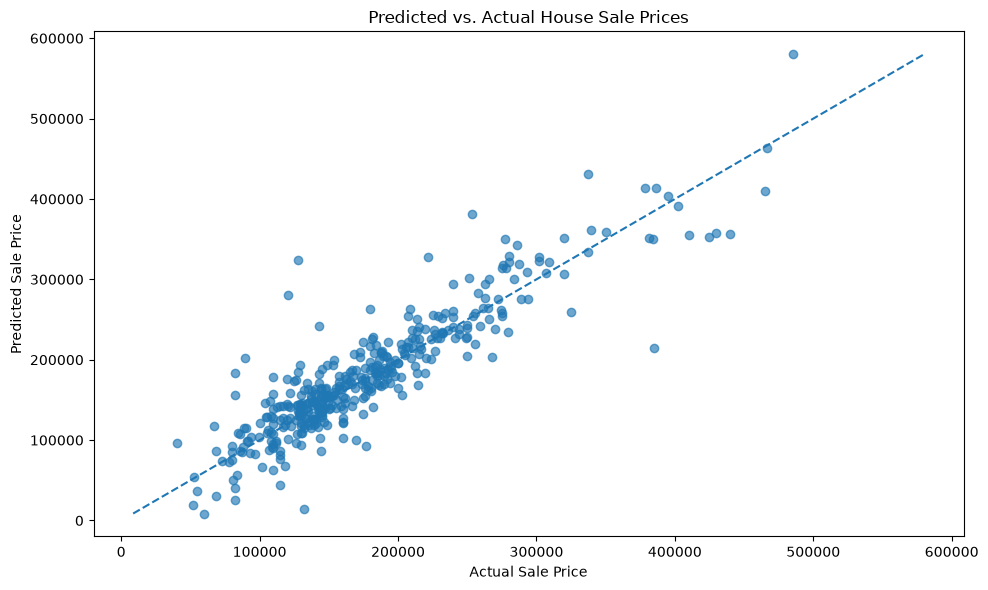

In [11]:
plot_df = predicted.select("prediction", "trueLabel").toPandas()

minimum = min(plot_df["prediction"].min(), plot_df["trueLabel"].min())
maximum = max(plot_df["prediction"].max(), plot_df["trueLabel"].max())

plt.figure(figsize=(10, 6))
plt.scatter(plot_df["trueLabel"], plot_df["prediction"], alpha=0.65)
plt.plot([minimum, maximum], [minimum, maximum], linestyle="--")
plt.title("Predicted vs. Actual House Sale Prices")
plt.xlabel("Actual Sale Price")
plt.ylabel("Predicted Sale Price")
plt.tight_layout()
plt.show()

## 8. Evaluate the regression model

The notebook reports three common regression metrics:

- **RMSE**: penalizes large prediction errors and is measured in sale-price units
- **MAE**: average absolute prediction error, also measured in sale-price units
- **$R^2$**: proportion of target variance explained by the model

In [12]:
def evaluate(metric_name: str) -> float:
    evaluator = RegressionEvaluator(
        labelCol="trueLabel",
        predictionCol="prediction",
        metricName=metric_name,
    )
    return evaluator.evaluate(predicted)

rmse = evaluate("rmse")
mae = evaluate("mae")
r2 = evaluate("r2")

print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"Mean Absolute Error (MAE):      ${mae:,.2f}")
print(f"R²:                             {r2:.4f}")

Root Mean Squared Error (RMSE): $34,064.57
Mean Absolute Error (MAE):      $23,154.67
R²:                             0.7902


## 9. Inspect model coefficients

The final pipeline stage is the fitted `LinearRegressionModel`. Its summary provides additional diagnostics about model fit and optimization.

In [13]:
lr_model = pipeline_model.stages[-1]

print(f"Number of coefficients: {len(lr_model.coefficients)}")
print(f"Intercept: ${lr_model.intercept:,.2f}")
print(f"Training RMSE: ${lr_model.summary.rootMeanSquaredError:,.2f}")
print(f"Training R²: {lr_model.summary.r2:.4f}")

Number of coefficients: 809
Intercept: $-269,903.19
Training RMSE: $9,950.77
Training R²: 0.9850


## 10. Stop Spark

Stopping the Spark session releases local resources when the notebook work is complete.

In [14]:
spark.stop()

## Suggested exercises

1. Compare linear regression with `RandomForestRegressor` and `GBTRegressor`.
2. Remove low-value predictors and compare RMSE.
3. Apply a logarithmic transformation to `SalePrice` and evaluate the effect.
4. Tune `regParam` and `elasticNetParam` with `CrossValidator`.
5. Save the fitted pipeline and reload it for inference.